# How the first benchmark was found to be broken

A lab notebook, in the order the work happened. It reads committed files only:
`reports/evaluation_2026-09-02.json` for the questions that were replaced,
`data/questions/reference_qa.json` for the ones that ship, and `data/raw/events.json`
for the corpus. No model is called and nothing is written: the published artefacts
are written by scripts, which is what lets a manifest say where each of them comes
from.

The story in short: the first evaluation set scored `recall@1` = 1.00, which is not a
result but a symptom. This notebook is how that was established.

In [1]:
import json
from collections import Counter

from events_rag.evaluation.difficulty import content_tokens, lexical_overlap, measure_question_set
from events_rag.utils.paths import DATA_DIR, REPORTS_DIR

archive = json.loads((REPORTS_DIR / 'evaluation_2026-09-02.json').read_text(encoding='utf-8'))
shipped = json.loads((DATA_DIR / 'questions' / 'reference_qa.json').read_text(encoding='utf-8'))
events = {
    event['metadata']['uid']: event['text']
    for event in json.loads((DATA_DIR / 'raw' / 'events.json').read_text(encoding='utf-8'))
    if (event.get('metadata') or {}).get('uid')
}

len(archive['results']), len(shipped), len(events)

(30, 30, 1000)

## The symptom

The first ablation gave the dense baseline `recall@1` = 1.00 over twenty questions:
every question retrieved its source event in first position. A benchmark with no
headroom cannot rank anything, which is the whole reason an ablation exists.

The tell was one row below. `bm25-only` is a bag of words with no embeddings at all,
and it reached 0.90 `recall@5` over a thousand events. That does not happen on
questions someone would actually ask.

In [2]:
# The generated questions, as they were asked on 2026-09-02.
for case in archive['results'][:4]:
    print(case['id'], '|', case['question'])

q01 | Quel événement célèbre les 20 ans d'un atelier vélo à Montpellier en mai 2025 ?
q02 | Où et quand se déroule la lecture musicale « Songes capturés » en hommage à Max Rouquette ?
q03 | Quel spectacle adapté aux enfants est programmé à l'Agora de la Cité Internationale de la Danse à Montpellier le 20 septembre 2025 ?
q04 | Où et quand a lieu la visite guidée gratuite sur la comédie à Montpellier en septembre 2025 ?


## The cause

Read the four questions above again: each one carries a proper noun straight out of
its event. `Goma Espérance` occurs once in the whole corpus, so matching that string
is enough to find the event, and no understanding is involved.

`lexical_overlap` turns that observation into a number: the share of a question's
content words — four characters or more, accents folded — that appear verbatim in the
event it should retrieve.

In [3]:
# The overlap of a generated question with the answer that was returned for it: the
# event itself is gone, and this is the closest text the archive still holds.
case = archive['results'][0]
shared = sorted(content_tokens(case['question']) & content_tokens(case['ground_truth']))
print(case['question'])
print()
print('shared with the ground truth of its own event:', shared)
print('overlap:', round(lexical_overlap(case['question'], case['ground_truth']), 2))

Quel événement célèbre les 20 ans d'un atelier vélo à Montpellier en mai 2025 ?

shared with the ground truth of its own event: ['2025', 'montpellier']
overlap: 0.29


The event itself is out of reach, and the cell below says why: that run answered from
Montpellier alone, and almost nothing it cites survives in what ships today.

In [4]:
cited = [source['uid'] for row in archive['results'] for source in (row['sources'] or [])]
still_here = [uid for uid in cited if uid in events]
towns = {source['city'] for row in archive['results'] for source in (row['sources'] or [])}
print(f'{len(still_here)} of {len(cited)} cited events are in the committed corpus')
print('towns the archived run answered from:', sorted(towns))

2 of 139 cited events are in the committed corpus
towns the archived run answered from: ['Montpellier']


Hence the 0.61 quoted for the generated set: a number kept as history, with no way to
produce it again here. Everything below runs on what ships.

In [5]:
measured = measure_question_set(shipped, events)
print(measured['definition'])
print()
print('questions measured:', measured['cases_measured'])
print('mean overlap:', measured['mean_lexical_overlap'])

Fraction of a question's content words (four characters or more, accents folded) that appear verbatim in the event it was written from.

questions measured: 20
mean overlap: 0.5


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


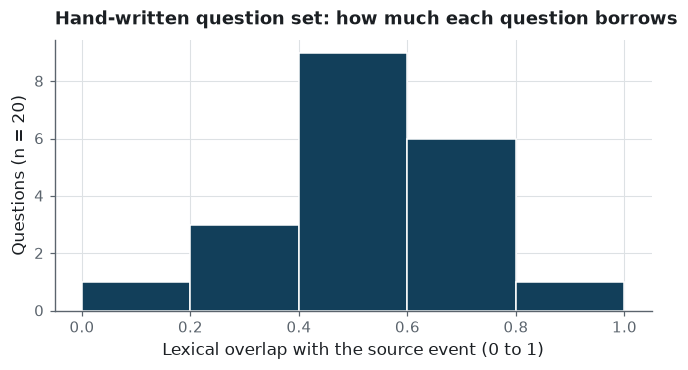

In [6]:
import matplotlib.pyplot as plt

from events_rag.figure_style import PALETTE, apply_style

apply_style()
overlaps = [row['lexical_overlap'] for row in measured['per_case']]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(overlaps, bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], color=PALETTE['primary'], edgecolor='white')
ax.set_xlabel('Lexical overlap with the source event (0 to 1)')
ax.set_ylabel(f'Questions (n = {len(overlaps)})')
ax.set_title('Hand-written question set: how much each question borrows')
plt.show()

## What the residue is made of

The overlap does not fall to zero, and it should not. A question about an outing names
the town, and the town is in the event. Below are the words that the highest-overlap
questions share with their event: proper nouns a user says out loud.

In [7]:
by_uid = {row['source_uid']: row for row in measured['per_case']}
worst = sorted(measured['per_case'], key=lambda row: -row['lexical_overlap'])[:3]
asked = {case['id']: case for case in shipped}

for row in worst:
    case = asked[row['id']]
    shared = sorted(content_tokens(case['question']) & content_tokens(events[row['source_uid']]))
    print(f"{row['id']}  overlap {row['lexical_overlap']}")
    print('   ', case['question'])
    print('    shared:', ', '.join(shared))
    print()

q10  overlap 0.875
    Un spectacle bilingue en occitan et en français, gratuit, à Issus en décembre — où exactement ?
    shared: bilingue, decembre, francais, gratuit, issus, occitan, spectacle

q03  overlap 0.667
    Y a-t-il un concert de chant choral dans une église à Lavaur en septembre, et faut-il réserver ?
    shared: chant, choral, concert, dans, eglise, lavaur

q16  overlap 0.667
    Un château ouvre gratuitement son domaine à Lisle-sur-Tarn pour les journées du patrimoine, on peut y découvrir quoi ?
    shared: chateau, domaine, journees, lisle, ouvre, patrimoine, pour, tarn



In [8]:
# How often a shared word is a town name, over the whole set.
towns = {
    token
    for event in json.loads((DATA_DIR / 'raw' / 'events.json').read_text(encoding='utf-8'))
    for token in content_tokens((event.get('metadata') or {}).get('city') or '')
}
shared_words = Counter()
for row in measured['per_case']:
    case = asked[row['id']]
    event_text = events[row['source_uid']]
    shared_words.update(content_tokens(case['question']) & content_tokens(event_text))

in_towns = sum(count for word, count in shared_words.items() if word in towns)
print('shared word occurrences:', sum(shared_words.values()))
print('of which town names:', in_towns)
print('most shared:', shared_words.most_common(8))

shared word occurrences: 97
of which town names: 24
most shared: [('dans', 4), ('toulouse', 3), ('atelier', 3), ('concert', 2), ('pour', 2), ('ales', 2), ('theatre', 2), ('gratuit', 2)]


`dans` and `pour` are in that list, which is the heuristic showing its edge: four
characters or more skips most French function words and not all of them. The measure
is meant to compare two question sets against the same corpus, and a constant bias
on both sides is exactly what it tolerates.

## What changed, and what it cost

The rewrite kept the seeded sample, so the same twenty events are still the targets
and no question was dropped for being hard. Every score in the ablation fell with the
overlap. `bm25-only` fell hardest, which is the signature of a lexical shortcut being
removed, and the dense baseline left the ceiling, which is what lets the ablation
separate anything at all.

The seven configurations on this set are in
[`02_retrieval_ablation.ipynb`](02_retrieval_ablation.ipynb); the protocol is in
[`../docs/protocol.md`](../docs/protocol.md).